In [ ]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [ ]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [ ]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [ ]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        row, col = state

        for action, (dr, dc) in MOVES.items():

          # Compute neighbour cell
          new_row = row + dr
          new_col = col + dc
          new_state = (new_row, new_col)

          # Check that it is in bounds and free
          if self.in_bounds(new_state) and self.is_free(new_state):
            legal_actions.append(action)

        # Return legal_actions
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4: In this lab, each valid move has a cost of 1
        return 1

In [ ]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")


GridProblem self-check passed.


In [ ]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

print(f"Grid size: {len(sample_grid)} x {len(sample_grid[0])}")
print(f"Start position: {start}")
print(f"Goal position: {goal}")
print(f"Is start free? {problem.is_free(start)}")
print(f"Is goal free? {problem.is_free(goal)}")
print(f"Actions from start: {problem.actions(start)}")

Grid size: 10 x 10
Start position: (0, 0)
Goal position: (9, 9)
Is start free? True
Is goal free? True
Actions from start: ['RIGHT']


In [ ]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

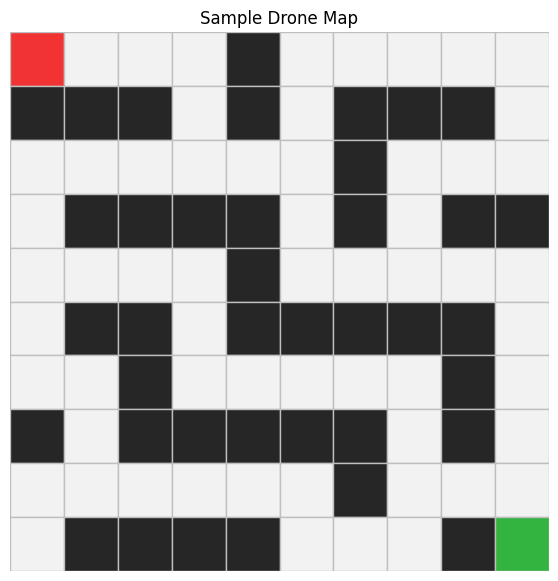

In [ ]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5: Implement the AIMA-style EXPAND(problem, node)
        # Get the current state from the node
        s=node.state

        # For each legal action from this state
        for action in problem.actions(s):
          s_prime = problem.result(s, action)
          # Calculate the new path cost
          cost = node.path_cost + problem.action_cost(s, action, s_prime)

          # Create and yield a new node
          yield Node (
              state=s_prime,
              parent=node,
              action=action,
              path_cost=cost,
              depth=node.depth+1
          )

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [ ]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.

        # Steps:
        # 1. Create the initial node from problem.initial_state().

        initial_node = Node(problem.initial_state()) # Fixed: call the method

        # 2. If the initial state is the goal, return success.

        if problem.is_goal(initial_node.state):
          return SearchResult(
              algorithm=algorithm,
              status="success",
              solution=initial_node,
              nodes_expanded=0,
              max_frontier_size=1,
              reached_count=1
          )
        # 3. Create a deque frontier and add the initial node.

        from collections import deque
        frontier = deque([initial_node]) # Fixed: add the Node object, not just its state

        # 4. Create a reached set and add the initial state.

        reached = {initial_node.state}

        # Initialize metrics

        nodes_expanded = 0
        max_frontier_size= len(frontier)

        # 5. While frontier is not empty:
        while frontier: # Added `while frontier:` loop
            # a. pop from the LEFT of the deque.
            node = frontier.popleft()

            # b. increment nodes_expanded.
            nodes_expanded+=1

            # c. expand the node.
            for child in self.expand(problem, node):
            #d i. if child is goal, return success
              if problem.is_goal(child.state):
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=child,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached)
                )

                #d ii. if child.state is not reached
              if child.state not in reached: # Moved this line to correct indentation
                # add child.state to reached
                reached.add(child.state)
                # append child to frontier
                frontier.append(child)
                # e. update max_frontier_size
                max_frontier_size = max(max_frontier_size, len(frontier))

        # 6. Return failure if no solution is found.
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )


In [ ]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        # Steps:
        # 1. Create the initial node.
        initial_node=Node(problem.initial_state())

        # 2. If the initial state is the goal, return success.
        if problem.is_goal(initial_node.state):
          return SearchResult(
              algorithm=algorithm,
              status="success",
              solution=initial_node,
              nodes_expanded=0,
              max_frontier_size=1,
              reached_count=1
          )
        # 3. Use a Python list as the stack frontier.
        frontier = [initial_node]

        # 4. Use a reached set.
        reached = {initial_node.state}

        #Initialize metrics
        nodes_expanded=0
        max_frontier_size=len(frontier)

        # 5. While frontier is not empty:
        while frontier:
          # a.pop from the end of the list
          node = frontier.pop() # Renamed 'nodes' to 'node'
          # b. increment nodes_expanded.
          nodes_expanded+=1

          # c. expand the node
          # IMPORTANT FIX: Pass the 'node' argument to expand
          children = list(self.expand(problem, node))

          #d. add unreached children to the stack
          for child in reversed(children):
            if problem.is_goal(child.state):
              return SearchResult(
                  algorithm=algorithm,
                  status="success",
                  solution=child,
                  nodes_expanded=nodes_expanded,
                  max_frontier_size=max_frontier_size,
                  reached_count=len(reached)
              )
            # Fixed indentation for the if block below
            if child.state not in reached:
                  reached.add(child.state)
                  frontier.append(child)

            # Update max_frontier_size inside the loop where frontier changes
            max_frontier_size = max(max_frontier_size, len(frontier))

        # 6. Return failure if no solution is found (Moved outside the while loop)
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )


In [ ]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # 1. If node.state is goal, return (node, "success")
        if problem.is_goal(node.state):
            return node, "success"

        # 2. Else if node.depth >= limit, return (None, "cutoff")
        if node.depth >= limit:
            return None, "cutoff"

        # 3. Otherwise:
        # a. increment metrics["nodes_expanded"]
        metrics["nodes_expanded"] += 1

        # b. set cutoff_occurred = False
        cutoff_occurred = False

        # c. for each child in expand(problem, node)
        for child in self.expand(problem, node):
            # i. skip the child if child.state already appears on the current path
            if state_is_on_path(node, child.state):
                continue

            # ii. update max_stack_size
            new_stack_size = current_stack_size + 1
            metrics["max_stack_size"] = max(metrics["max_stack_size"], new_stack_size)

            # iii. recursively call _recursive_dls on the child
            result, status = self._recursive_dls(
                problem=problem,
                node=child,
                limit=limit,
                metrics=metrics,
                current_stack_size=new_stack_size
            )

            # iv. if result is "success", return success immediately
            if status == "success":
                return result, "success"

            # v. if result is "cutoff", set cutoff_occurred = True
            if status == "cutoff":
                cutoff_occurred = True

        # d. after all children
        if cutoff_occurred:
            return None, "cutoff"
        else:
            return None, "failure"


In [ ]:
# Cell: IDS Implementation
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # 1. Keep a list called iteration_log
        iteration_log = []

        # Accumulate total nodes expanded across all DLS iterations
        total_nodes_expanded = 0

        # Track the maximum stack size seen in any DLS run
        overall_max_stack = 0

        # Track the reached count (note: IDS doesn't maintain global reached set)
        # We'll track the solution when found

        solution_node = None
        final_status = "cutoff"  # default if we hit max_depth without success

        # 2. For limit from 0 to max_depth
        for limit in range(max_depth + 1):
            # Create a new DLS instance for each iteration
            dls = DepthLimitedSearch()

            # Run DLS with current limit
            result = dls.search(problem, limit=limit)

            # Record the limit and status in the iteration log
            iteration_log.append({
                "limit": limit,
                "status": result.status,
                "nodes_expanded": result.nodes_expanded,
                "max_stack": result.max_frontier_size
            })

            # Accumulate metrics
            total_nodes_expanded += result.nodes_expanded
            overall_max_stack = max(overall_max_stack, result.max_frontier_size)

            # 3. If status = success then return result
            if result.status == "success":
                solution_node = result.solution
                final_status = "success"
                break

            # 4. Else if status = failure then return failure
            elif result.status == "failure":
                final_status = "failure"
                break

            # 5. Otherwise (cutoff), continue to next limit

        # Create the final SearchResult
        return SearchResult(
            algorithm=algorithm,
            status=final_status,
            solution=solution_node,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=overall_max_stack,
            reached_count=0,
            limit=max_depth,
            iterations=iteration_log
        )



In [ ]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

       # 1. Keep a list called iteration_log
        iteration_log = []

        # Accumulate total nodes expanded across all DLS iterations
        total_nodes_expanded = 0

        # Track the maximum stack size seen in any DLS run
        overall_max_stack = 0


        solution_node = None
        final_status = "cutoff"

        # 2. For limit from 0 to max_depth
        for limit in range(max_depth + 1):
            # Create a new DLS instance for each iteration
            dls = DepthLimitedSearch()

            # Run DLS with current limit
            result = dls.search(problem, limit=limit)

            # Record the limit and status in the iteration log
            iteration_log.append({
                "limit": limit,
                "status": result.status,
                "nodes_expanded": result.nodes_expanded,
                "max_stack": result.max_frontier_size
            })

            # Accumulate metrics
            total_nodes_expanded += result.nodes_expanded
            overall_max_stack = max(overall_max_stack, result.max_frontier_size)

            # 3. If status = success then return result
            if result.status == "success":
                solution_node = result.solution
                final_status = "success"
                break

            # 4. Else if status = failure then return failure
            elif result.status == "failure":
                final_status = "failure"
                break

            # 5. Otherwise (cutoff), continue to next limit

        # Create the final SearchResult
        return SearchResult(
            algorithm=algorithm,
            status=final_status,
            solution=solution_node,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=overall_max_stack,
            reached_count=0,  # IDS doesn't maintain global reached set
            limit=max_depth,
            iterations=iteration_log
        )

In [ ]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,26.0,26.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,30.0,18.0,18.0,356,19,0


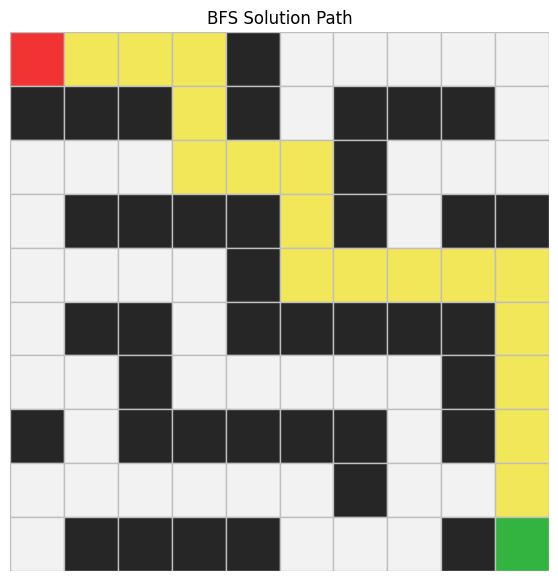

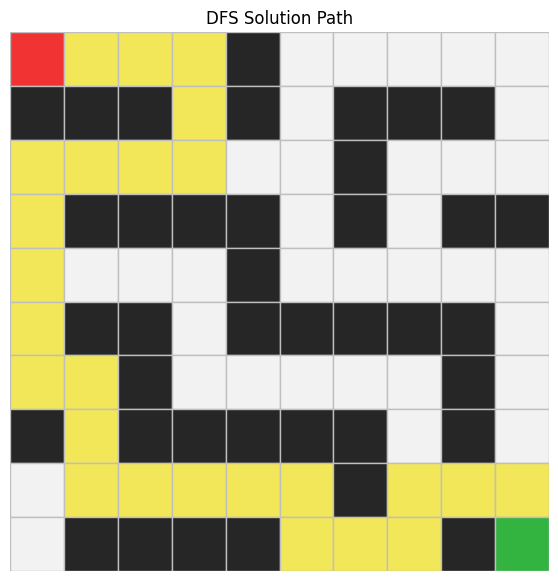

In [ ]:
bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

CUSTOM MAP 1: Long Corridor with Dead Ends
Grid size: 15 x 15
Start: (0, 0)
Goal: (14, 14)


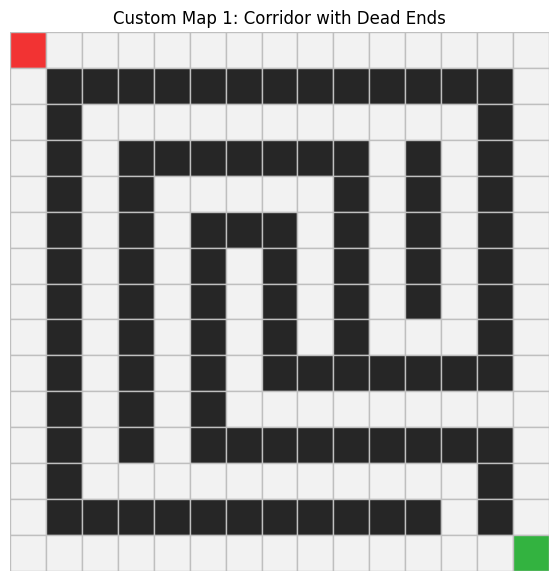


Running algorithms on Custom Map 1...

CUSTOM MAP 1 RESULTS
  Algorithm   Status  Limit  Solution depth  Solution cost  Nodes expanded  Max frontier/stack  Reached states
0       BFS  success    NaN              28             28              57                   4              60
1       DFS  success    NaN              28             28              89                   4              90
2       DLS  success   50.0              28             28              64                  51               0
3       IDS  success   60.0              28             28             761                  29               0

Visualizing BFS solution for Custom Map 1...


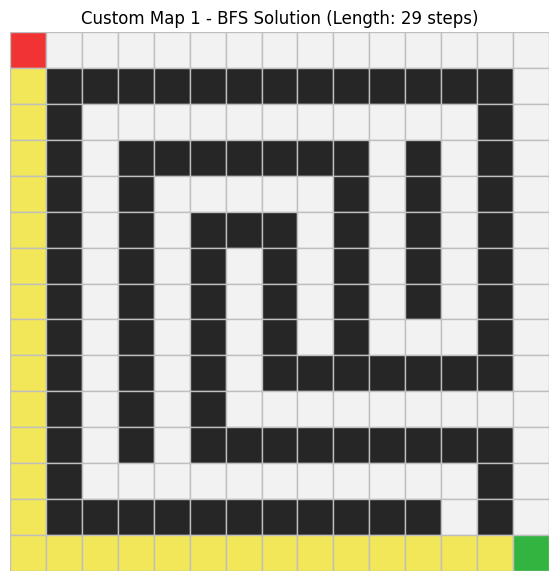

In [ ]:
# Cell 14.1: First custom map - Long winding corridor with dead ends
# This map tests how algorithms handle deep paths with false leads

custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (14, 14)

# Create the problem instance
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

print("=" * 70)
print("CUSTOM MAP 1: Long Corridor with Dead Ends")
print("=" * 70)
print(f"Grid size: {len(custom_grid_1)} x {len(custom_grid_1[0])}")
print(f"Start: {custom_start_1}")
print(f"Goal: {custom_goal_1}")

# Visualize the map without path
plot_path(custom_grid_1, custom_start_1, custom_goal_1, title="Custom Map 1: Corridor with Dead Ends")

# Run all algorithms on custom map 1
print("\nRunning algorithms on Custom Map 1...")
bfs1 = BreadthFirstSearch()
dfs1 = DepthFirstSearch()
dls1 = DepthLimitedSearch()
ids1 = IterativeDeepeningSearch()

bfs_result1 = bfs1.search(custom_problem_1)
dfs_result1 = dfs1.search(custom_problem_1)
dls_result1 = dls1.search(custom_problem_1, limit=50)
ids_result1 = ids1.search(custom_problem_1, max_depth=60)

custom_results_1 = [bfs_result1, dfs_result1, dls_result1, ids_result1]

print("\n" + "=" * 70)
print("CUSTOM MAP 1 RESULTS")
print("=" * 70)
custom_df1 = show_results(custom_results_1)
print(custom_df1.to_string())

# Visualize BFS solution for map 1
if bfs_result1.solution:
    print("\nVisualizing BFS solution for Custom Map 1...")
    plot_path(
        custom_grid_1,
        custom_start_1,
        custom_goal_1,
        path=bfs_result1.path,
        title=f"Custom Map 1 - BFS Solution (Length: {len(bfs_result1.path)} steps)"
    )

#Interpretation
In this maze, there is a very long winding corridor with dead ends along the way. BFS can find the shortest path effectively. DFS might have to dive deep into dead ends before discovering the goal, thus exploring more nodes. DLS with depth limit=20 fails if the path to the solution is deeper than 20 nodes.

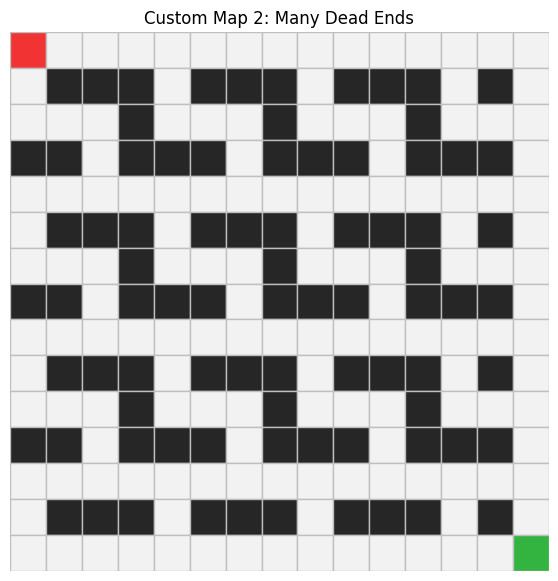

CUSTOM MAP 2 RESULTS
  Algorithm   Status  Limit  Solution depth  Solution cost  Nodes expanded  Max frontier/stack  Reached states
0       BFS  success    NaN            28.0           28.0             138                   8             142
1       DFS  success    NaN            96.0           96.0             129                  21             142
2       DLS   cutoff   20.0             NaN            NaN             207                  21               0
3       IDS  success   40.0            28.0           28.0            4679                  29               0


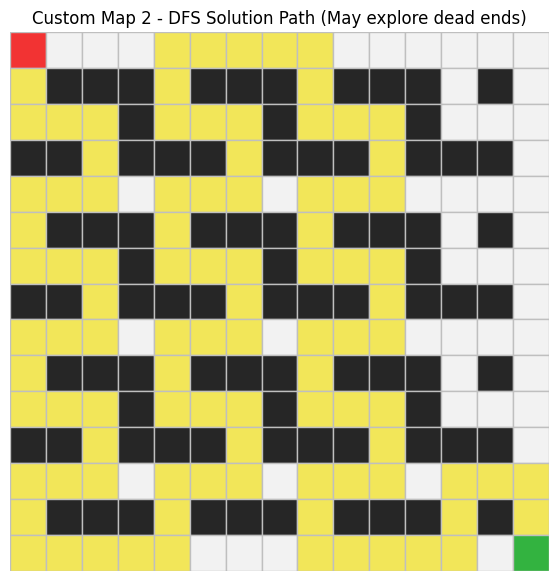

In [ ]:
# TODO 11: Second custom map - Many dead ends (WITH VISUALIZATION)

custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (14, 14)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

# Visualize the map first
plot_path(custom_grid_2, custom_start_2, custom_goal_2, title="Custom Map 2: Many Dead Ends")

# Run algorithms
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
print("CUSTOM MAP 2 RESULTS")
results_df_2 = show_results(custom_results_2)
print(results_df_2.to_string())

# Visualize DFS solution path for Map 2 (to show how DFS explores dead ends)
dfs_result_2 = custom_results_2[1]
if dfs_result_2.solution:
    plot_path(
        custom_grid_2,
        custom_start_2,
        custom_goal_2,
        path=dfs_result_2.path,
        title="Custom Map 2 - DFS Solution Path (May explore dead ends)"
    )

#Interpretation
The map consists of numerous dead-end branches from the main path. DFS would end up exploring the dead ends prior to locating the goal, thus expanding many nodes. BFS systematically expands the nodes level by level, ensuring that it locates the optimum solution without getting lost in dead-end branches. Depth-Limited Search with a cutoff of 20 could provide a solution if the appropriate depth was reached.

# Reflection Questions

15.1 Problem Formulation

1. What is a state in this lab?

- A state is tuple (row, col) representating the drone's current position, e.g (0,0).

2. What is an action?

- An action is one of the four movements, "UP", "DOWN", "LEFT" or "RIGHT".

3. What does the result function do?

- The result function takes a state and an action and returns a new state after the application of an action. For example result((0,0), "RIGHT") retuens (0,1).

4. Why is it useful to separate the problem definition from the search algorithm

- With separation, the exact same set of search algorithms (BFS, DFS, DLS, IDS) can be applied to all domains, such as grid movement, puzzles, routing, etc., without change. The Problem class provides an interface that guarantees each algorithm just calls the actions(), result(), and is_goal() methods. This ensures code reuse, testability, and follows the encapsulation principle.

15.2 BFS

1. Why does BFS use a FIFO queue?

- BFS uses a FIFO queue because it needs to explore nodes in the order they are discovered. By removing from the front and adding to the back, nodes at depth d a processed before any nodes at depth d+1. This ensures shallow nodes are explored before the deeper ones.

2. Why does BFS find the shortest path in terms of number of steps on the unweighted grid?

- Given that each step has an identical cost of 1, BFS will explore all solutions with d steps prior to any solution of d+1 steps. Therefore, when BFS discovers the goal state for the first time, its solution would be the shortest one possible.

3. What role does the reached set play in BFS?

- The reached state stores all the states that have already been visited. When generating child nodes, BFS only adds a child to the frontier if its state is not already in reached. This prevents revisiting states, avoids infinite loops in cyclic graphs, and significantly reduces the number of nodes expanded.

15.3 DFS

1. Why does DFS use a stack?

- DFS uses stack because it needs to explore the most recently discovered node first. Through use of append() and pop() operations from the last position of the stack, DFS explores one path until it reaches a dead-end point.

2. Is DFS guaranteed to find the shortest path? Explain.

- No, DFS is not guaranteed to find the shortest path. DFS may find the longer path if it goes in a suboptimal direction and reaches the goal before exploring shorter alternatives from other branch.

3. Under what conditions can DFS use less memory than BFS?

- DFS uses less memory than BFS in deep search spaces because it only stores the current path from the start to where it's exploring (O(depth) memory), while BFS has to store every node at the current level (O(branching factor^depth) memory). This memory advantage is most noticeable when the goal is far down a narrow path with many branches, as BFS would have to remember all those branching alternatives while DFS just keeps going down one path. However, this efficiency comes at a cost—DFS might find a much longer path or get stuck exploring useless deep branches before finding the solution.

4. Under what conditions can DFS perform badly?

- DFS performs badly in infinite state spaces or graphs with cycles (without cycle detection), where it may never terminate. It also performs poorly when the goal is shallow but DFS explores a very deep, useless branch first.

15.4 DLS

1. What happens when the depth limit is too small?

- When the depth limit is too small, DLS returns a "cutoff" status without finding a solution, even if a solution exists beyond the limit.

What is the meaning of "cutoff"?

- Cutoff means the search reached the depth limit before either finding a goal or ehausting all possibilities.

2. How is DLS different from ordinary DFS?

- DLS artificially stops exploring at a maximum depth limit, while DFS continues until no more states exist or the goal is found. DLS uses path-cycle checking instead of a global reached set, and it returns three statuses ("success", "cutoff", "failure") rather than just success or failure.

3. Why do we use path-cycle checking in DLS?

DLS uses path-cycle checking state_is_on_path() instead of a global reached set because a global set would break the depth-limiting behavior. Without global tracking, DLS can revisit the same state through different paths, but path-cycle checking prevents infinite recursion on the current branch. A global reached set would prevent exploring a state that was reached at a shallower depth, which might be necessary to find a solution within the limit.

15.5 IDS

1. Why does IDS repeat DLS with increasing limits?

- IDS repeats DLS with increasing limits to combine DFS's memory efficiency with BFS's completeness. It finds the shallowest solution first without storing the entire frontier, which would be required by BFS.

2. Why can IDS be complete even though DLS with a small limit is not?

- By iteratively increasing the depth limit, IDS will eventually reach any finite solution depth. Even though DLS with a small limit may return "cutoff", IDS keeps increasing the limit until it either finds the solution or proves none exists (up to max_depth).

3. Why does IDS use less memory than BFS?
What is the cost of repeatedly searching from the root?

- Each DLS iteration uses O(depth) memory (like DFS), not O(branching_factor^depth) like BFS. Even though IDS re-explores nodes multiple times, memory usage stays low. In my results, IDS used a maximum stack size of 19, while BFS used a frontier size of 5 - actually BFS used less memory here because the tree was shallow. For deeper trees, IDS would have an advantage.

What is the cost of repeatedly searching from the root?

IDS re-expands nodes multiple times - approximately O(b^d) total nodes for a tree of depth d and branching factor b. This is about b/(b-1) times more than BFS, which is a small constant factor (e.g., ~1.33 for b=4). In your notebook, IDS expanded 356 nodes total, much more than BFS's 50, demonstrating this overhead.

15.6 Real-World Drone Context

1. In a real drone application, what might make one route safer or more practical than another?

- These include not flying over areas of water or forest (obstacles in this lab setting), staying away from restricted areas, line-of-sight communication requirements, areas of high wind or turbulence, low energy use, not flying over populated areas for safety reasons, and the terrain difficulty (like not flying up a steep hill).

2. Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.

- BFS would be the best choice because it guarantees finding the shortest path in an unweighted grid. The results show BFS found a path of depth 18 while DFS found depth 26.

3. Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.

- DLS (Depth-Limited Search) with an adequate depth limit would be suitable. If your drone has limited energy supply and cannot move further than 20 moves, you could use limit=20. Your DLS would only search for solutions up to that depth and give you "cutoff" when there is no solution in those depths.

4. What limitations does this grid model have compared with real drone navigation?

- Practical drone navigation includes continuous coordinate systems (as opposed to discrete grid cells), 3-dimensional movement with change in altitudes, dynamic obstacles (moving obstacles and weather conditions), noise and uncertainties in sensors, time limits, different costs of terrain (such as flying over water takes more energy), limitations in communication channels, no-fly areas, energy usage that is affected by more than just the number of steps taken, and the need to avoid collisions. Grids assume perfect information and deterministic movement, which do not exist in reality.

